<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Data Normalization Techniques**


Estimated time needed: **30** minutes


In this lab, you will focus on data normalization. This includes identifying compensation-related columns, applying normalization techniques, and visualizing the data distributions.


## Objectives


In this lab, you will perform the following:


- Identify duplicate rows and remove them.

- Check and handle missing values in key columns.

- Identify and normalize compensation-related columns.

- Visualize the effect of normalization techniques on data distributions.


-----


## Hands on Lab


#### Step 1: Install and Import Libraries


In [2]:
!pip install pandas
print("Successful!")

Successful!


In [1]:
!pip install matplotlib
print("Successful!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 150.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 134.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 82.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 137.8 MB/s eta 0:00:00
Successful!


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
print("Successful!")

Successful!


### Step 2: Load the Dataset into a DataFrame


We use the <code>pandas.read_csv()</code> function for reading CSV files. However, in this version of the lab, which operates on JupyterLite, the dataset needs to be downloaded to the interface using the provided code below.


The functions below will download the dataset into your browser:


In [ ]:
file_path ="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/UDKAZw-kz18Yj8P6icf_qw/survey-data-duplicates.csv"

df = pd.read_csv(file_path)

# Display the first few rows to check if data is loaded correctly
print(df.head())


In [ ]:
#df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/UDKAZw-kz18Yj8P6icf_qw/survey-data-duplicates.csv")

### Section 1: Handling Duplicates
##### Task 1: Identify and remove duplicate rows.


In [7]:
## Write your code here
import pandas as pd

# Load dataset
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/UDKAZw-kz18Yj8P6icf_qw/survey-data-duplicates.csv"

df = pd.read_csv(file_path)

# Count duplicate rows
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

# Display first few duplicate rows
print(df[df.duplicated()].head())

# Remove duplicate rows
df = df.drop_duplicates()

# Check dataset after removing duplicates
print("Dataset shape after removing duplicates:", df.shape)

Number of duplicate rows: 10
       ResponseId                      MainBranch                 Age  \
65437           1  I am a developer by profession  Under 18 years old   
65438           2  I am a developer by profession     35-44 years old   
65439           3  I am a developer by profession     45-54 years old   
65440           4           I am learning to code     18-24 years old   
65441           5  I am a developer by profession     18-24 years old   

                Employment RemoteWork   Check  \
65437  Employed, full-time     Remote  Apples   
65438  Employed, full-time     Remote  Apples   
65439  Employed, full-time     Remote  Apples   
65440   Student, full-time        NaN  Apples   
65441   Student, full-time        NaN  Apples   

                                        CodingActivities  \
65437                                              Hobby   
65438  Hobby;Contribute to open-source projects;Other...   
65439  Hobby;Contribute to open-source projects;Other... 

### Section 2: Handling Missing Values
##### Task 2: Identify missing values in `CodingActivities`.


In [8]:
## Write your code here

# Count missing values in CodingActivities column
missing_coding_activities = df['CodingActivities'].isnull().sum()

print("Number of missing values in CodingActivities:", missing_coding_activities)

# Display rows with missing CodingActivities values
print(df[df['CodingActivities'].isnull()].head())

Number of missing values in CodingActivities: 10971
    ResponseId                                         MainBranch  \
3            4                              I am learning to code   
4            5                     I am a developer by profession   
5            6                        I code primarily as a hobby   
7            8                              I am learning to code   
13          14  I used to be a developer by profession, but no...   

                   Age                                         Employment  \
3      18-24 years old                                 Student, full-time   
4      18-24 years old                                 Student, full-time   
5   Under 18 years old                                 Student, full-time   
7      18-24 years old  Student, full-time;Not employed, but looking f...   
13     35-44 years old             Not employed, and not looking for work   

   RemoteWork   Check CodingActivities  \
3         NaN  Apples       

##### Task 3: Impute missing values in CodingActivities with forward-fill.


In [11]:
## Write your code here

# Fill missing values using the previous row's value
df['CodingActivities'] = df['CodingActivities'].ffill()

# Check if missing values remain
print("Missing values after forward-fill:", df['CodingActivities'].isnull().sum())

Missing values after forward-fill: 0


**Note**:  Before normalizing ConvertedCompYearly, ensure that any missing values (NaN) in this column are handled appropriately. You can choose to either drop the rows containing NaN or replace the missing values with a suitable statistic (e.g., median or mean).


### Section 3: Normalizing Compensation Data
##### Task 4: Identify compensation-related columns, such as ConvertedCompYearly.
Normalization is commonly applied to compensation data to bring values within a comparable range. Here, you’ll identify ConvertedCompYearly or similar columns, which contain compensation information. This column will be used in the subsequent tasks for normalization.


In [12]:
## Write your code here

# Find columns related to compensation
compensation_columns = [col for col in df.columns if 'Comp' in col or 'Salary' in col or 'Pay' in col]

print("Compensation-related columns:")
print(compensation_columns)

Compensation-related columns:
['CompTotal', 'AIComplex', 'ConvertedCompYearly']


##### Task 5: Normalize ConvertedCompYearly using Min-Max Scaling.
Min-Max Scaling brings all values in a column to a 0-1 range, making it useful for comparing data across different scales. Here, you will apply Min-Max normalization to the ConvertedCompYearly column, creating a new column ConvertedCompYearly_MinMax with normalized values.


In [16]:
## Write your code here


# Apply Min-Max scaling manually
df['ConvertedCompYearly_MinMax'] = (
    (df['ConvertedCompYearly'] - df['ConvertedCompYearly'].min()) /
    (df['ConvertedCompYearly'].max() - df['ConvertedCompYearly'].min())
)


# Display first few rows
print(df[['ConvertedCompYearly', 'ConvertedCompYearly_MinMax']].head())

print("Minimum:", df['ConvertedCompYearly_MinMax'].min())
print("Maximum:", df['ConvertedCompYearly_MinMax'].max())

   ConvertedCompYearly  ConvertedCompYearly_MinMax
0                  NaN                         NaN
1                  NaN                         NaN
2                  NaN                         NaN
3                  NaN                         NaN
4                  NaN                         NaN
Minimum: 0.0
Maximum: 1.0


##### Task 6: Apply Z-score Normalization to `ConvertedCompYearly`.

Z-score normalization standardizes values by converting them to a distribution with a mean of 0 and a standard deviation of 1. This method is helpful for datasets with a Gaussian (normal) distribution. Here, you’ll calculate Z-scores for the ConvertedCompYearly column, saving the results in a new column ConvertedCompYearly_Zscore.


In [17]:
## Write your code here

# Calculate Z-score normalization
df['ConvertedCompYearly_Zscore'] = (
    (df['ConvertedCompYearly'] - df['ConvertedCompYearly'].mean()) /
    df['ConvertedCompYearly'].std()
)

# Display first few rows
print(df[['ConvertedCompYearly', 'ConvertedCompYearly_Zscore']].head())

   ConvertedCompYearly  ConvertedCompYearly_Zscore
0                  NaN                         NaN
1                  NaN                         NaN
2                  NaN                         NaN
3                  NaN                         NaN
4                  NaN                         NaN


### Section 4: Visualization of Normalized Data
##### Task 7: Visualize the distribution of `ConvertedCompYearly`, `ConvertedCompYearly_Normalized`, and `ConvertedCompYearly_Zscore`

Visualization helps you understand how normalization changes the data distribution. In this task, create histograms for the original ConvertedCompYearly, as well as its normalized versions (ConvertedCompYearly_MinMax and ConvertedCompYearly_Zscore). This will help you compare how each normalization technique affects the data range and distribution.


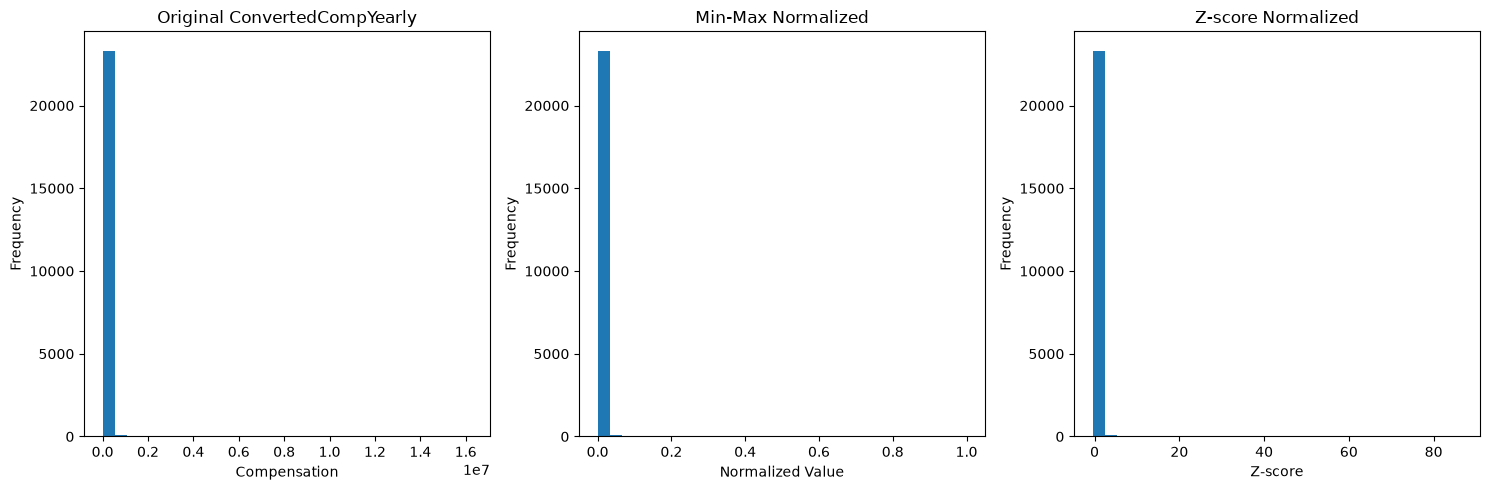

In [18]:
## Write your code here
import matplotlib.pyplot as plt

# Create figure
plt.figure(figsize=(15, 5))

# Histogram of original compensation
plt.subplot(1, 3, 1)
plt.hist(df['ConvertedCompYearly'].dropna(), bins=30)
plt.title('Original ConvertedCompYearly')
plt.xlabel('Compensation')
plt.ylabel('Frequency')

# Histogram of Min-Max normalized data
plt.subplot(1, 3, 2)
plt.hist(df['ConvertedCompYearly_MinMax'].dropna(), bins=30)
plt.title('Min-Max Normalized')
plt.xlabel('Normalized Value')
plt.ylabel('Frequency')

# Histogram of Z-score normalized data
plt.subplot(1, 3, 3)
plt.hist(df['ConvertedCompYearly_Zscore'].dropna(), bins=30)
plt.title('Z-score Normalized')
plt.xlabel('Z-score')
plt.ylabel('Frequency')

# Adjust layout
plt.tight_layout()

# Display plots
plt.show()

### Summary


In this lab, you practiced essential normalization techniques, including:

- Identifying and handling duplicate rows.

- Checking for and imputing missing values.

- Applying Min-Max scaling and Z-score normalization to compensation data.

- Visualizing the impact of normalization on data distribution.


Copyright © IBM Corporation. All rights reserved.
